In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
# Create Power grid graph
G = nx.Graph()

# Substations(nodes)
substations = [
    ("Sub_A", {"voltage": 132, "city": "Miami"}),
    ("Sub_B", {"voltage": 220, "city": "Orlando"}),
    ("Sub_C", {"voltage": 132, "city": "Tampa"}),
    ("Sub_D", {"voltage": 220, "city": "Jacksonville"}),
    ("Sub_E", {"voltage": 132, "city": "Gainesville"}),
    ("Sub_F", {"voltage": 132, "city": "Tallahassee"}),
]
G.add_nodes_from(substations)

# Transmission lines(edges + weight = capacity)
lines = [
    ("Sub_A", "Sub_B", {"capacity": 0.08}),
    ("Sub_A", "Sub_C", {"capacity": 0.05}),
    ("Sub_B", "Sub_C", {"capacity": 0.09}),
    ("Sub_B", "Sub_D", {"capacity": 0.02}),
    ("Sub_C", "Sub_E", {"capacity": 0.06}),
    ("Sub_D", "Sub_E", {"capacity": 0.03}),
    ("Sub_D", "Sub_F", {"capacity": 0.02}),
    ("Sub_E", "Sub_F", {"capacity": 0.07}),
]
G.add_edges_from(lines)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Neighbors of Sub_B: {list(G.neighbors('Sub_B'))}")

Nodes: 6
Edges: 8
Neighbors of Sub_B: ['Sub_A', 'Sub_C', 'Sub_D']


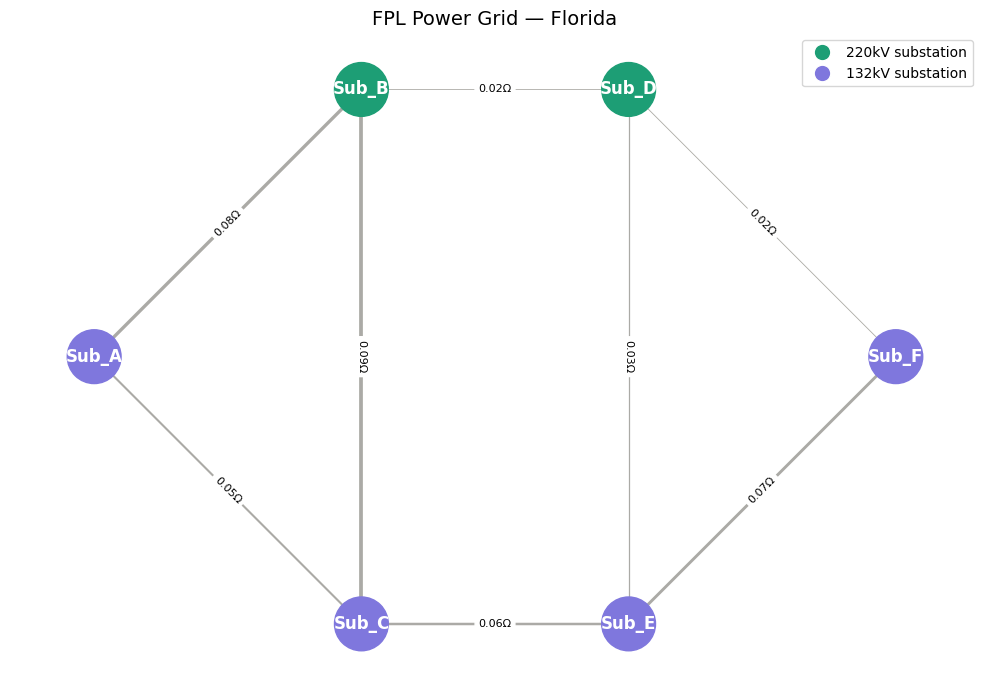

In [10]:
plt.figure(figsize=(10, 7))

# Layout — nodes position
pos = {
    "Sub_A": (0, 1),
    "Sub_B": (1, 2),
    "Sub_C": (1, 0),
    "Sub_D": (2, 2),
    "Sub_E": (2, 0),
    "Sub_F": (3, 1),
}

# Node color — as per voltage level
node_colors = [
    "#1D9E75" if G.nodes[n]["voltage"] == 220 else "#7F77DD" 
    for n in G.nodes()
]

# Edge thickness — as per capacity
edge_weights = [G[u][v]["capacity"] * 30 for u, v in G.edges()]

# Draw
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color="#888780", alpha=0.7)

# Edge capacity labels
edge_labels = {(u, v): f"{d['capacity']}Ω" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

plt.title("FPL Power Grid — Florida", fontsize=14)
plt.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=12, label='220kV substation'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#7F77DD', markersize=12, label='132kV substation'),
    ]
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:

    # Cell 4 — Teen centrality metrics ek saath
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="capacity")
pagerank = nx.pagerank(G, weight="capacity")

# Saara data ek table mein laao
df = pd.DataFrame({
    "Substation": list(G.nodes()),
    "City": [G.nodes[n]["city"] for n in G.nodes()],
    "Voltage (kV)": [G.nodes[n]["voltage"] for n in G.nodes()],
    "Degree": [round(degree_centrality[n], 3) for n in G.nodes()],
    "Betweenness": [round(betweenness_centrality[n], 3) for n in G.nodes()],
    "PageRank": [round(pagerank[n], 3) for n in G.nodes()],
})

# Betweenness se sort karo — sabse critical upar
df = df.sort_values("Betweenness", ascending=False).reset_index(drop=True)

print(df.to_string(index=False))

Substation         City  Voltage (kV)  Degree  Betweenness  PageRank
     Sub_D Jacksonville           220     0.6          0.5     0.099
     Sub_B      Orlando           220     0.6          0.2     0.211
     Sub_E  Gainesville           132     0.6          0.2     0.199
     Sub_C        Tampa           132     0.6          0.1     0.221
     Sub_A        Miami           132     0.4          0.0     0.148
     Sub_F  Tallahassee           132     0.4          0.0     0.123


In [12]:
# Cell 5 — Node size = PageRank, Color = Betweenness risk
plt.figure(figsize=(12, 8))

pos = {
    "Sub_A": (0, 1),
    "Sub_B": (1, 2),
    "Sub_C": (1, 0),
    "Sub_D": (2, 2),
    "Sub_E": (2, 0),
    "Sub_F": (3, 1),
}

# Node size — PageRank se (zyada important = bada circle)
node_sizes = [pagerank[n] * 8000 for n in G.nodes()]

# Node color — Betweenness se (risk level)
def risk_color(node):
    b = betweenness_centrality[node]
    if b >= 0.4:
        return "#E05252"    # Red — critical risk
    elif b >= 0.15:
        return "#F0A500"    # Orange — medium risk
    else:
        return "#1D9E75"    # Green — low risk

node_colors = [risk_color(n) for n in G.nodes()]

# Edge thickness — capacity se
edge_weights

[2.4,
 1.5,
 2.6999999999999997,
 0.6,
 1.7999999999999998,
 0.8999999999999999,
 0.6,
 2.1]

<Figure size 1200x800 with 0 Axes>

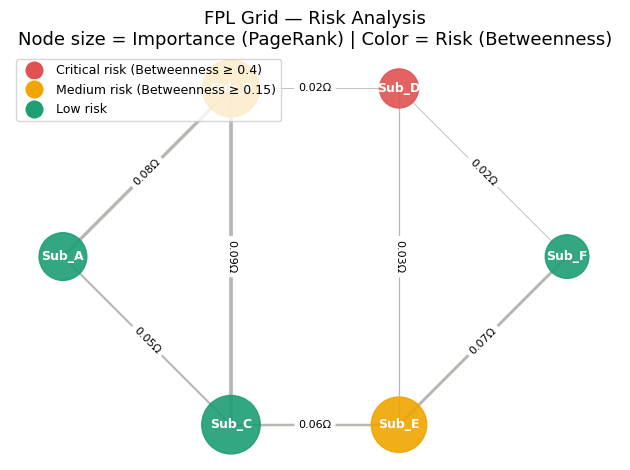

In [13]:
# Draw
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", font_size=9)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color="#888780", alpha=0.6)

edge_labels = {(u, v): f"{d['capacity']}Ω" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E05252', markersize=14, label='Critical risk (Betweenness ≥ 0.4)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F0A500', markersize=14, label='Medium risk (Betweenness ≥ 0.15)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=14, label='Low risk'),
]
plt.legend(handles=legend_elements, loc="upper left", fontsize=9)
plt.title("FPL Grid — Risk Analysis\nNode size = Importance (PageRank) | Color = Risk (Betweenness)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()
